In [ ]:
!pip install underthesea gensim fasttext emoji lightgbm catboost

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import unicodedata
import fasttext
import emoji
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, roc_auc_score,
    average_precision_score, auc, brier_score_loss
)
from sklearn.calibration import calibration_curve
from underthesea import word_tokenize

Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/MyDrive/CommentClassificationDataset/train_full.csv"
data = pd.read_csv(DATA_PATH)

print(data.columns)
print(data.head())
print("\nCount:\n", data["is_violation"].value_counts(dropna=False))
print("\nRatio:\n", data["is_violation"].value_counts(normalize=True, dropna=False))

data["comment"] = data["comment"].astype(str).fillna("")
data["is_violation"] = data["is_violation"].astype(int)

original_comments = data['comment'].values
y = data['is_violation'].values

Index(['comment', 'is_violation'], dtype='object')
                                             comment  is_violation
0                                                cặc           1.0
1                   đr hết thời cày rank bk còn ngợp           0.0
2         Diễn viên hô ni hút mà ngại gì mấy khác kk           0.0
3  Toàn bọn vô công rồi nghề ngồi sủa ăn lương th...           1.0
4  lên kim cương bố ỉa vào mồm mày với cái lối lê...           1.0

Count:
 is_violation
1.0    3668
0.0    2684
Name: count, dtype: int64

Ratio:
 is_violation
1.0    0.577456
0.0    0.422544
Name: proportion, dtype: float64


In [ ]:
def preprocess_basic(text):
    if not isinstance(text, str):
        text = str(text)
    text = unicodedata.normalize('NFC', text)
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    return tokens

data['tokens'] = data['comment'].apply(preprocess_basic)
print("Sample tokens:", data['tokens'].iloc[0])

X_tokens = data['tokens'].values

Sample tokens: ['cặc']


In [ ]:
indices = np.arange(len(data))

train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, stratify=y, random_state=42
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=y[temp_idx], random_state=42
)

X_train = X_tokens[train_idx]
X_val = X_tokens[val_idx]
X_test = X_tokens[test_idx]

y_train = y[train_idx]
y_val = y[val_idx]
y_test = y[test_idx]

train_comments = original_comments[train_idx]
val_comments = original_comments[val_idx]
test_comments = original_comments[test_idx]

print("Train:", len(X_train))
print("Val  :", len(X_val))
print("Test :", len(X_test))

print("TRAIN ratio:\n", pd.Series(y_train).value_counts(normalize=True))
print("VAL ratio:\n", pd.Series(y_val).value_counts(normalize=True))
print("TEST ratio:\n", pd.Series(y_test).value_counts(normalize=True))

Train: 4446
Val  : 953
Test : 953
TRAIN ratio:
 1    0.577373
0    0.422627
Name: proportion, dtype: float64
VAL ratio:
 1    0.578174
0    0.421826
Name: proportion, dtype: float64
TEST ratio:
 1    0.577125
0    0.422875
Name: proportion, dtype: float64


In [ ]:
!wget -O cc.vi.300.bin.gz https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.vi.300.bin.gz
!gunzip -f cc.vi.300.bin.gz

ft_model = fasttext.load_model('cc.vi.300.bin')
print("FastText model loaded. Vector dimension:", ft_model.get_dimension())

--2026-05-09 04:05:36--  https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.vi.300.bin.gz
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.171.22.33, 3.171.22.118, 3.171.22.13, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.171.22.33|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4504817955 (4.2G) [application/octet-stream]
Saving to: ‘cc.vi.300.bin.gz’

cc.vi.300.bin.gz    100%[===================>]   4.20G  86.8MB/s    in 35s     

2026-05-09 04:06:12 (121 MB/s) - ‘cc.vi.300.bin.gz’ saved [4504817955/4504817955]

FastText model loaded. Vector dimension: 300


In [ ]:
train_strings = [' '.join(tokens) for tokens in X_train]
val_strings = [' '.join(tokens) for tokens in X_val]
test_strings = [' '.join(tokens) for tokens in X_test]

tfidf = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b', min_df=1, max_df=1.0)
tfidf.fit(train_strings)

def get_weighted_average_vector(sentence, tfidf_vectorizer, w2v_model, vec_size=300):
    tfidf_vec = tfidf_vectorizer.transform([sentence])
    feature_names = tfidf_vectorizer.get_feature_names_out()
    weights = tfidf_vec.toarray()[0]
    weighted_sum = np.zeros(vec_size)
    total_weight = 0.0
    for word, w in zip(feature_names, weights):
        if w > 0:
            vec = w2v_model.get_word_vector(word)
            weighted_sum += w * vec
            total_weight += w
    if total_weight > 0:
        return weighted_sum / total_weight
    else:
        return np.zeros(vec_size)

X_train_vec = np.array([get_weighted_average_vector(s, tfidf, ft_model, 300) for s in train_strings])
X_val_vec = np.array([get_weighted_average_vector(s, tfidf, ft_model, 300) for s in val_strings])
X_test_vec = np.array([get_weighted_average_vector(s, tfidf, ft_model, 300) for s in test_strings])

print("Shape X_train_vec:", X_train_vec.shape)

Shape X_train_vec: (4446, 300)


In [ ]:
# Block 8 (sửa) – GridSearchCV cho CatBoost
param_grid = {
    'iterations': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [3, 5, 7],
    'l2_leaf_reg': [1, 3, 5],
    'border_count': [32, 64]
}

# Tạo model cơ bản với auto_class_weights='Balanced' (tương đương class_weight='balanced')
cat_base = CatBoostClassifier(
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=0
)

grid_search = GridSearchCV(
    estimator=cat_base,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("===== BẮT ĐẦU GRID SEARCH CATBOOST =====")
grid_search.fit(X_train_vec, y_train)
print("Best params:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_)

cat_model = grid_search.best_estimator_
print("CatBoost with best params training completed.")

===== BẮT ĐẦU GRID SEARCH CATBOOST =====
Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best params: {'border_count': 64, 'depth': 7, 'iterations': 200, 'l2_leaf_reg': 5, 'learning_rate': 0.1}
Best CV F1: 0.8422071109886171
CatBoost with best params training completed.


In [ ]:
y_val_prob = cat_model.predict_proba(X_val_vec)[:, 1]

cost_configs = [
    {"name": "cost_1_5", "fp": 1.0, "fn": 5.0},
    {"name": "cost_1_3", "fp": 1.0, "fn": 3.0},
    {"name": "cost_1_2", "fp": 1.0, "fn": 2.0},
    {"name": "cost_2_5", "fp": 2.0, "fn": 5.0},
]
fixed_thresholds = [0.30, 0.32, 0.35, 0.38, 0.40, 0.42]

def evaluate_threshold(y_true, y_prob, thresh, cost_fp, cost_fn):
    y_pred = (y_prob >= thresh).astype(int)
    n_pos = np.sum(y_true)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = n_pos - tp
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / n_pos if n_pos > 0 else 0
    f1 = 2 * prec * rec / (prec + rec + 1e-8)
    cost = fp * cost_fp + fn * cost_fn
    return {"threshold": thresh, "precision": prec, "recall": rec, "f1": f1, "fp": fp, "fn": fn, "cost": cost}

candidates = []
for cfg in cost_configs:
    prec, rec, thresholds = precision_recall_curve(y_val, y_val_prob)
    best_cost = np.inf
    best_info = None
    for i, th in enumerate(thresholds):
        info = evaluate_threshold(y_val, y_val_prob, th, cfg["fp"], cfg["fn"])
        if info["cost"] < best_cost:
            best_cost = info["cost"]
            best_info = info
    candidates.append(best_info)

for th in fixed_thresholds:
    info = evaluate_threshold(y_val, y_val_prob, th, 1.0, 5.0)
    candidates.append(info)

print("\n===== CANDIDATE THRESHOLDS (on validation) =====")
for cand in candidates:
    print(f"th={cand['threshold']:.4f} | prec={cand['precision']:.4f} | rec={cand['recall']:.4f} | f1={cand['f1']:.4f} | fp={cand['fp']} | fn={cand['fn']}")

best_candidate = max(candidates, key=lambda x: x['f1'])
best_threshold = best_candidate['threshold']
print(f"\n=== Chọn ngưỡng theo F1 max: {best_threshold:.4f} (F1={best_candidate['f1']:.4f}, precision={best_candidate['precision']:.4f}, recall={best_candidate['recall']:.4f}) ===")


===== CANDIDATE THRESHOLDS (on validation) =====
th=0.1023 | prec=0.6821 | rec=0.9891 | f1=0.8074 | fp=254 | fn=6
th=0.3203 | prec=0.8213 | rec=0.9256 | f1=0.8703 | fp=111 | fn=41
th=0.3203 | prec=0.8213 | rec=0.9256 | f1=0.8703 | fp=111 | fn=41
th=0.3203 | prec=0.8213 | rec=0.9256 | f1=0.8703 | fp=111 | fn=41
th=0.3000 | prec=0.8076 | rec=0.9292 | f1=0.8641 | fp=122 | fn=39
th=0.3200 | prec=0.8213 | rec=0.9256 | f1=0.8703 | fp=111 | fn=41
th=0.3500 | prec=0.8317 | rec=0.9147 | f1=0.8712 | fp=102 | fn=47
th=0.3800 | prec=0.8399 | rec=0.8947 | f1=0.8664 | fp=94 | fn=58
th=0.4000 | prec=0.8484 | rec=0.8838 | f1=0.8658 | fp=87 | fn=64
th=0.4200 | prec=0.8584 | rec=0.8802 | f1=0.8692 | fp=80 | fn=66

=== Chọn ngưỡng theo F1 max: 0.3500 (F1=0.8712, precision=0.8317, recall=0.9147) ===


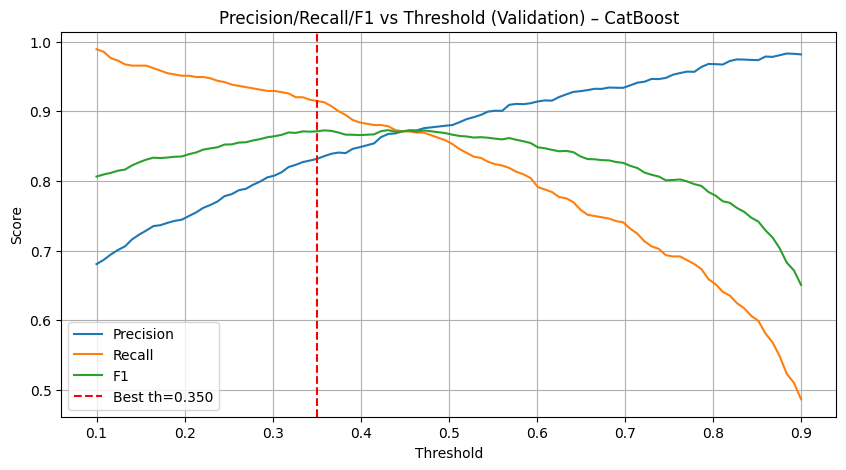

In [ ]:
thresholds = np.linspace(0.1, 0.9, 100)
precs = []
recs = []
f1s = []
for th in thresholds:
    y_pred = (y_val_prob >= th).astype(int)
    tp = np.sum((y_val == 1) & (y_pred == 1))
    fp = np.sum((y_val == 0) & (y_pred == 1))
    fn = np.sum((y_val == 1) & (y_pred == 0))
    prec = tp / (tp + fp) if (tp+fp)>0 else 0
    rec = tp / np.sum(y_val) if np.sum(y_val)>0 else 0
    f1 = 2*prec*rec/(prec+rec+1e-8)
    precs.append(prec)
    recs.append(rec)
    f1s.append(f1)

plt.figure(figsize=(10,5))
plt.plot(thresholds, precs, label='Precision')
plt.plot(thresholds, recs, label='Recall')
plt.plot(thresholds, f1s, label='F1')
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best th={best_threshold:.3f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision/Recall/F1 vs Threshold (Validation) – CatBoost')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def evaluate_model(model, X_vec, y_true, threshold, split_name="DATA"):
    y_prob = model.predict_proba(X_vec)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    print(f"\n===== {split_name} =====")
    print(f"ROC-AUC : {roc_auc:.4f}")
    print(f"PR-AUC  : {pr_auc:.4f}")
    print(classification_report(y_true, y_pred, digits=4))
    print(confusion_matrix(y_true, y_pred))
    return y_prob, y_pred

In [ ]:
y_train_prob, y_train_pred = evaluate_model(cat_model, X_train_vec, y_train, best_threshold, "TRAIN")
y_val_prob, y_val_pred = evaluate_model(cat_model, X_val_vec, y_val, best_threshold, "VALIDATION")
y_test_prob, y_test_pred = evaluate_model(cat_model, X_test_vec, y_test, best_threshold, "TEST")


===== TRAIN =====
ROC-AUC : 0.9999
PR-AUC  : 1.0000
              precision    recall  f1-score   support

           0     0.9995    0.9947    0.9971      1879
           1     0.9961    0.9996    0.9979      2567

    accuracy                         0.9975      4446
   macro avg     0.9978    0.9971    0.9975      4446
weighted avg     0.9975    0.9975    0.9975      4446

[[1869   10]
 [   1 2566]]

===== VALIDATION =====
ROC-AUC : 0.9261
PR-AUC  : 0.9489
              precision    recall  f1-score   support

           0     0.8646    0.7463    0.8011       402
           1     0.8317    0.9147    0.8712       551

    accuracy                         0.8437       953
   macro avg     0.8481    0.8305    0.8361       953
weighted avg     0.8455    0.8437    0.8416       953

[[300 102]
 [ 47 504]]

===== TEST =====
ROC-AUC : 0.9199
PR-AUC  : 0.9435
              precision    recall  f1-score   support

           0     0.8541    0.6973    0.7678       403
           1     0.8045 

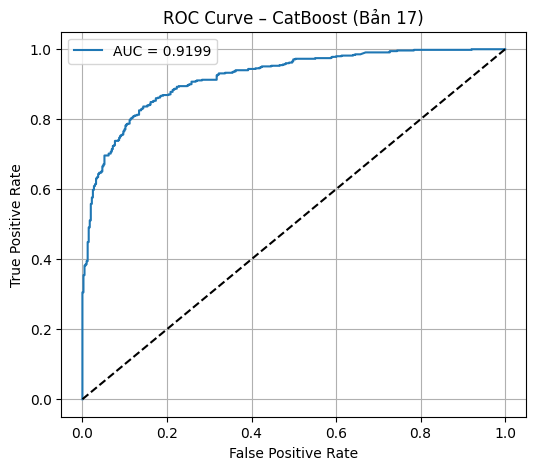

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – CatBoost (Bản 17)")
plt.legend()
plt.grid(True)
plt.show()

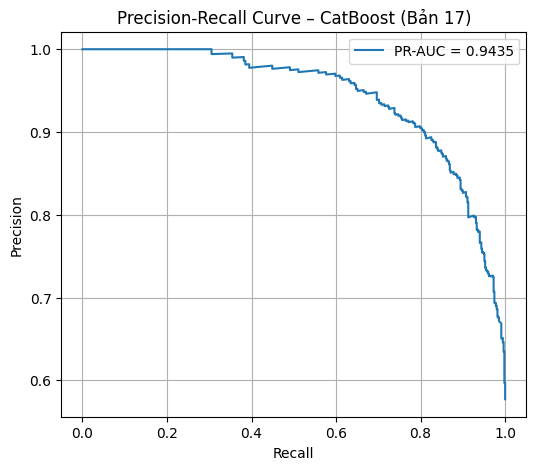

In [ ]:
precision, recall, _ = precision_recall_curve(y_test, y_test_prob)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve – CatBoost (Bản 17)")
plt.legend()
plt.grid(True)
plt.show()

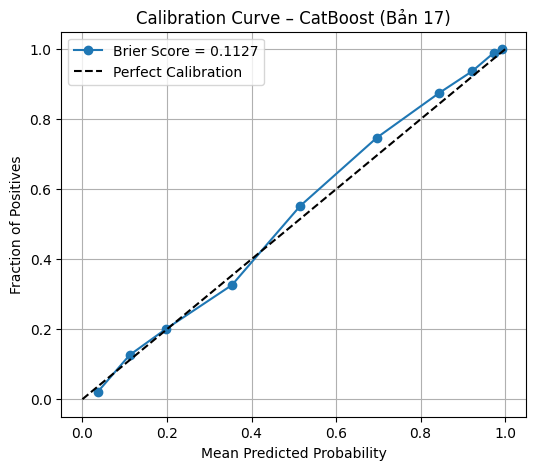

In [ ]:
frac_pos, mean_pred = calibration_curve(y_test, y_test_prob, n_bins=10, strategy='quantile')
brier = brier_score_loss(y_test, y_test_prob)

plt.figure(figsize=(6,5))
plt.plot(mean_pred, frac_pos, marker='o', label=f"Brier Score = {brier:.4f}")
plt.plot([0,1],[0,1], 'k--', label="Perfect Calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve – CatBoost (Bản 17)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
cv_scores = cross_validate(
    cat_model,
    X_train_vec, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision"
    },
    return_train_score=False,
    n_jobs=-1
)

print("\n===== CROSS-VALIDATION (5-fold) – CatBoost (Bản 17) =====")
for metric in cv_scores:
    if metric.startswith("test_"):
        vals = cv_scores[metric]
        print(f"{metric}: {vals.mean():.4f} +/- {vals.std():.4f}")


===== CROSS-VALIDATION (5-fold) – CatBoost (Bản 17) =====
test_accuracy: 0.8221 +/- 0.0124
test_precision: 0.8486 +/- 0.0109
test_recall: 0.8422 +/- 0.0199
test_f1: 0.8453 +/- 0.0117
test_roc_auc: 0.9001 +/- 0.0160
test_pr_auc: 0.9263 +/- 0.0133


In [ ]:
def show_fp_fn_samples_comments(comments, y_true, y_pred, y_prob, n=10):
    df = pd.DataFrame({
        "comment": comments,
        "true_label": y_true,
        "pred_label": y_pred,
        "prob_violation": y_prob
    })
    fp = df[(df["true_label"] == 0) & (df["pred_label"] == 1)]
    fn = df[(df["true_label"] == 1) & (df["pred_label"] == 0)]

    print(f"\n===== FALSE POSITIVES (Total: {len(fp)}) – CatBoost (Bản 17) =====")
    if len(fp) > 0:
        print(fp.sort_values("prob_violation", ascending=False).head(n)[["prob_violation", "comment"]])
    else:
        print("No false positives found!")

    print(f"\n===== FALSE NEGATIVES (Total: {len(fn)}) – CatBoost (Bản 17) =====")
    if len(fn) > 0:
        print(fn.sort_values("prob_violation", ascending=True).head(n)[["prob_violation", "comment"]])
    else:
        print("No false negatives found!")

show_fp_fn_samples_comments(test_comments, y_test, y_test_pred, y_test_prob, n=10)


===== FALSE POSITIVES (Total: 122) – CatBoost (Bản 17) =====
     prob_violation                                            comment
310        0.963852  Mày coi lại não mày load hết được cmt tao chưa...
259        0.947150                                        chó bị bệnh
48         0.937683                Con chó nó ngửi được mùi thằng trộm
882        0.936046         Vcl fb fake mà các bố cmt nhưu thật sợ vcl
462        0.932586  Cứ bắt rồi thả về lại đi hành nghề trộm cắp th...
93         0.913390  Mai Hà vậy mày coi lại bình luận đầu tiên của ...
34         0.895386   Võ Thành Phước P đánh con nunu như zày là ez win
739        0.888892  Xin đừng tin ai ở cái xã hội này-lừa đảo , cướ...
485        0.869973                          Thanh Thảo quần què nầy 😪
352        0.850998                                 Mời Trần Đứa Bo đi

===== FALSE NEGATIVES (Total: 48) – CatBoost (Bản 17) =====
     prob_violation                                            comment
418        0.022846  r, h